# GRU with SHAP-Selected Union Features

This notebook is a variant of the original temporal forecasting model with one key change: instead of using all 49 sensor + time features, the input is restricted to the **union of the top-X sensor and top-Y demographic features** ranked by CatBoost SHAP importance for SIS and OHS separately.

Everything else mirrors the accepted paper:
- **FeatureGate**: SHAP-initialized learnable gates, one for SIS and one for OHS, applied to the union feature set
- **GRU + DecayAttention**: shared encoder with two target-specific recency-biased attention streams
- **18-item multi-task output**: 6 SIS items (1–5 scale) + 12 OHS items (0–4 scale)
- **Patient-grouped 5-fold CV**, leakage-safe temporal splits, same metrics

Demographic features are static per patient and are repeated at every time-step so the GRU sees patient context at each day.

In [1]:
from pathlib import Path
import copy
import math
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from torch.utils.data import Dataset, DataLoader

TOP_X_SENSOR = 10
TOP_Y_DEMO   = 5

SEED              = 42
FORECAST_GAP      = 7
BATCH_SIZE        = 12
MAX_EPOCHS        = 300
PATIENCE          = 45
LR                = 2e-3
WEIGHT_DECAY      = 1e-4
HIDDEN_DIM        = 48
DROPOUT           = 0.10
DECAY_RATE        = 0.08
TOTAL_LOSS_WEIGHT = 1.0

DEVICE   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR = Path.cwd()
SHAP_DIR = DATA_DIR / "catboost-shap"

sis_targets = [f"sis-{i:02d}" for i in range(1, 7)]
ohs_targets = [f"ohs-{i:02d}" for i in range(1, 13)]

def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)
plt.style.use("ggplot")
print(f"Device: {DEVICE}")
print(f"TOP_X_SENSOR={TOP_X_SENSOR}, TOP_Y_DEMO={TOP_Y_DEMO}")

Device: cpu
TOP_X_SENSOR=10, TOP_Y_DEMO=5


In [2]:
def ordered_union(a, b):
    seen = set(a)
    return a + [x for x in b if x not in seen]

sis_s = pd.read_csv(SHAP_DIR/"shap_catboost_sis_feature_importance.csv")["feature"].iloc[:TOP_X_SENSOR].tolist()
ohs_s = pd.read_csv(SHAP_DIR/"shap_catboost_ohs_feature_importance.csv")["feature"].iloc[:TOP_X_SENSOR].tolist()

sis_d = pd.read_csv(SHAP_DIR/"shap_catboost_demo_sis_feature_importance.csv")["feature"].iloc[:TOP_Y_DEMO].tolist()
ohs_d = pd.read_csv(SHAP_DIR/"shap_catboost_demo_ohs_feature_importance.csv")["feature"].iloc[:TOP_Y_DEMO].tolist()

n_sensor = len(ordered_union(sis_s, ohs_s))
n_demo   = len(ordered_union(sis_d, ohs_d))
print(f"n_sensor={n_sensor}, n_demo={n_demo}, total={n_sensor + n_demo}")

n_sensor=15, n_demo=6, total=21


## Feature Selection from SHAP CSVs

Top-X sensor features and top-Y demographic features are loaded separately for SIS and OHS from the pre-computed CatBoost SHAP importance rankings (`catboost-shap/` folder). The **union** of the two target-specific lists forms a single shared input feature set used by both prediction heads. Union ordering is deterministic: SIS-ranked features appear first, followed by any OHS features not already in the SIS list.

Because the SHAP CSVs rank all 46 sensor (or all 7 demographic) features — not just the top-X — every feature in the union has a valid SHAP importance value for both targets. This allows the FeatureGate priors to be constructed without any floor-value fallbacks.

In [3]:
def load_ranked_features(csv_path: Path, n: int) -> list:
    """Return the names of the top-n features from a SHAP importance CSV."""
    return pd.read_csv(csv_path)["feature"].iloc[:n].tolist()

def ordered_union(list_a: list, list_b: list) -> list:
    """Return list_a + items in list_b not already in list_a, preserving order."""
    seen = set(list_a)
    return list_a + [x for x in list_b if x not in seen]

# --- sensor features ---
sis_sensor_top  = load_ranked_features(SHAP_DIR / "shap_catboost_sis_feature_importance.csv", TOP_X_SENSOR)
ohs_sensor_top  = load_ranked_features(SHAP_DIR / "shap_catboost_ohs_feature_importance.csv", TOP_X_SENSOR)
union_sensor    = ordered_union(sis_sensor_top, ohs_sensor_top)

# --- demographic features ---
sis_demo_top    = load_ranked_features(SHAP_DIR / "shap_catboost_demo_sis_feature_importance.csv", TOP_Y_DEMO)
ohs_demo_top    = load_ranked_features(SHAP_DIR / "shap_catboost_demo_ohs_feature_importance.csv", TOP_Y_DEMO)
union_demo      = ordered_union(sis_demo_top, ohs_demo_top)

# Combined input feature list (sensor first, then demo)
input_cols  = union_sensor + union_demo
n_features  = len(input_cols)

print(f"Union sensor features ({len(union_sensor)}): {union_sensor}")
print(f"Union demo   features ({len(union_demo)}): {union_demo}")
print(f"Total input features per time-step: {n_features}")

Union sensor features (15): ['acceleration-movement-events-00to06', 'acceleration-mean', 'sleep-snoring', 'acceleration-minutes-with-data', 'acceleration-hours-with-data', 'sleep-heartrate-mean', 'step-count', 'sleep-deep', 'acceleration-movement-events-18to24', 'heartrate-mean', 'motion-mean', 'sleep-heartrate-min', 'acceleration-movement-events-12to18', 'acceleration-movement-events-06to12', 'motion-ratio']
Union demo   features (6): ['relationship', 'age', 'education', 'fracture-type', 'sex', 'work']
Total input features per time-step: 21


## SHAP Priors for FeatureGate Initialization

Each FeatureGate is initialized from the SHAP importance values of the corresponding target. For a given target, the prior vector is built by reading the SHAP weight for every feature in the union set from that target's full ranking CSV, then normalizing by the mean so the gate starts near 1.0 on average. This ensures the SIS gate emphasizes features ranked highly for SIS, while the OHS gate emphasizes features ranked highly for OHS.

In [4]:
def build_gate_prior(
    sensor_csv:  Path,
    demo_csv:    Path,
    sensor_cols: list,
    demo_cols:   list,
    floor:       float = 0.02,
) -> np.ndarray:
    """Build a normalized SHAP prior vector for FeatureGate initialization.

    Reads SHAP weights for every feature in sensor_cols and demo_cols from
    the provided CSVs (which rank all features, so no floor fallback is needed
    in practice). The combined vector is normalized by its mean so that the
    average gate weight starts at 1.0.
    """
    # Load sensor SHAP weights
    sensor_shap = pd.read_csv(sensor_csv).set_index("feature")["weights"].to_dict()
    sensor_prior = np.array([sensor_shap.get(c, floor) for c in sensor_cols], dtype=np.float32)

    # Load demographic SHAP weights
    demo_shap = pd.read_csv(demo_csv).set_index("feature")["weights"].to_dict()
    demo_prior = np.array([demo_shap.get(c, floor) for c in demo_cols], dtype=np.float32)

    # Concatenate and normalize so the mean gate weight starts at 1.0
    combined = np.concatenate([sensor_prior, demo_prior])
    return (combined / combined.mean()).astype(np.float32)


# Build priors for SIS and OHS gates over the shared union feature set
sis_prior = build_gate_prior(
    SHAP_DIR / "shap_catboost_sis_feature_importance.csv",
    SHAP_DIR / "shap_catboost_demo_sis_feature_importance.csv",
    union_sensor, union_demo,
)
ohs_prior = build_gate_prior(
    SHAP_DIR / "shap_catboost_ohs_feature_importance.csv",
    SHAP_DIR / "shap_catboost_demo_ohs_feature_importance.csv",
    union_sensor, union_demo,
)

# Display initial gate priorities
prior_df = pd.DataFrame({
    "feature"  : input_cols,
    "SIS prior": sis_prior.round(3),
    "OHS prior": ohs_prior.round(3),
}).sort_values("SIS prior", ascending=False)
display(prior_df.head(10))

,feature,SIS prior,OHS prior
15,relationship,2.624,1.418
16,age,2.400,2.780
17,education,2.057,1.762
18,fracture-type,2.056,1.957
0,acceleration-movement-events-00to06,1.230,1.227
1,acceleration-mean,1.142,2.504
2,sleep-snoring,1.079,0.745
3,acceleration-minutes-with-data,0.902,0.222
4,acceleration-hours-with-data,0.891,0.278
5,sleep-heartrate-mean,0.808,0.448


## Data Loading

Two CSV files are combined:
- `data/maison-llf-features.csv` — 1008 rows of daily sensor readings with clinical outcomes
- `data/maison-llf-demographics.csv` — 18 rows (one per patient); categorical columns are label-encoded to integers

In [5]:
# ── Sensor / clinical data ────────────────────────────────────────────────────
raw = pd.read_csv(
    DATA_DIR / "data" / "maison-llf-features.csv",
    parse_dates=["timestamp", "clinical-timestamp"]
).sort_values(["participant", "timestamp", "clinical-timestamp"]).reset_index(drop=True)

# Identify all 46 sensor columns (exclude IDs and clinical outcome columns)
id_cols       = ["participant", "timestamp", "clinical-timestamp"]
clinical_cols = (
    ["sis", "ohs", "oks", "tug", "chairstand"]
    + [f"sis-{i:02d}" for i in range(1, 7)]
    + [f"ohs-{i:02d}" for i in range(1, 13)]
    + [f"oks-{i:02d}" for i in range(1, 13)]
)
sensor_cols_all = [c for c in raw.columns if c not in id_cols + clinical_cols]

print(f"Features CSV: {len(raw)} rows, {raw['participant'].nunique()} patients")
print(f"All sensor columns ({len(sensor_cols_all)}): {sensor_cols_all}")

# ── Demographics ──────────────────────────────────────────────────────────────
demo_raw = pd.read_csv(DATA_DIR / "data" / "maison-llf-demographics.csv")

# Label-encode categorical columns (pandas >= 2.0 uses StringDtype, not object)
demo_encoded = demo_raw.copy()
label_maps   = {}
for col in [c for c in demo_raw.columns if c != "participant" and not pd.api.types.is_numeric_dtype(demo_raw[c])]:
    cats = sorted(demo_raw[col].dropna().unique())
    mapping = {c: float(i) for i, c in enumerate(cats)}
    demo_encoded[col] = demo_raw[col].map(mapping)
    label_maps[col] = mapping
for col in [c for c in demo_raw.columns if c != "participant" and pd.api.types.is_numeric_dtype(demo_raw[c])]:
    demo_encoded[col] = demo_raw[col].astype(float)

# Index by participant for O(1) lookup
demo_lookup = demo_encoded.set_index("participant").astype(float)
print(f"\nDemographic columns: {demo_lookup.columns.tolist()}")
print("Label maps:", {k: v for k, v in label_maps.items()})

Features CSV: 1008 rows, 18 patients
All sensor columns (46): ['acceleration-count', 'acceleration-mean', 'acceleration-std', 'acceleration-sum', 'acceleration-entropy', 'acceleration-kurtosis', 'acceleration-skew', 'acceleration-coefficient-of-variation', 'acceleration-minutes-with-data', 'acceleration-hours-with-data', 'acceleration-movement-events-00to06', 'acceleration-movement-events-06to12', 'acceleration-movement-events-12to18', 'acceleration-movement-events-18to24', 'acceleration-movement-events-24h', 'acceleration-intradaily-variability', 'heartrate-count', 'heartrate-min', 'heartrate-max', 'heartrate-mean', 'heartrate-std', 'heartrate-hours-with-data', 'motion-count', 'motion-ratio', 'motion-mean', 'motion-max', 'motion-max-timestamp', 'position-count', 'position-duration', 'position-distance-travelled', 'sleep-total', 'sleep-deep', 'sleep-light', 'sleep-rem', 'sleep-snoring', 'sleep-duration-to-sleep', 'sleep-duration-to-wakeup', 'sleep-wakeup-count', 'sleep-heartrate-mean',

## Build Temporal Examples

One example is generated per (patient, clinical assessment) pair. The sensor history window ends `FORECAST_GAP` days before the assessment timestamp, yielding expanding windows of 7, 21, 35, and 49 days for the four biweekly assessments.

Each example stores all 46 sensor columns (feature selection is applied later per fold inside the Dataset) and all demographic values for that patient.

In [6]:
def build_forecast_examples(features_df: pd.DataFrame, demo_lkp: pd.DataFrame, gap_days: int) -> list:
    """Build one example dict per (patient, clinical assessment) pair.

    Each dict contains:
        patient         : int
        clinical_time   : Timestamp — assessment date (prediction target)
        cutoff          : Timestamp — last allowed sensor date
        timestamps      : np.ndarray — dates in the sensor history window
        x_sensor_frame  : DataFrame (T, 46) — all sensor columns, unprocessed
        demo_values     : dict — all label-encoded demographics for this patient
        sis             : np.ndarray (6,) — SIS item scores at clinical_time
        ohs             : np.ndarray (12,) — OHS item scores at clinical_time
        sis_total       : float — SIS total score
        ohs_total       : float — OHS total score
    """
    examples = []
    for patient, pdf in features_df.groupby("participant", sort=True):
        pdf      = pdf.sort_values("timestamp")
        demo_row = demo_lkp.loc[patient].to_dict()   # static per patient

        for clinical_time, assess_rows in pdf.groupby("clinical-timestamp", sort=True):
            cutoff  = clinical_time - pd.Timedelta(days=gap_days)
            history = pdf.loc[pdf["timestamp"] <= cutoff].copy()
            if history.empty:
                continue
            tr = assess_rows.iloc[0]
            examples.append({
                "patient"      : int(patient),
                "clinical_time": clinical_time,
                "cutoff"       : cutoff,
                "timestamps"   : history["timestamp"].to_numpy(),
                # Store all sensor columns; union selection applied inside Dataset
                "x_sensor_frame": history[sensor_cols_all].copy(),
                # Static per patient — repeated across all T time-steps
                "demo_values"  : demo_row,
                "sis"          : tr[sis_targets].astype(float).to_numpy(),
                "ohs"          : tr[ohs_targets].astype(float).to_numpy(),
                "sis_total"    : float(tr["sis"]),
                "ohs_total"    : float(tr["ohs"]),
            })
    return examples


examples      = build_forecast_examples(raw, demo_lookup, FORECAST_GAP)
example_index = pd.DataFrame([{
    "patient"      : e["patient"],
    "clinical_time": e["clinical_time"],
    "history_days" : len(e["timestamps"]),
} for e in examples])

# Sanity checks
assert len(examples) == raw["participant"].nunique() * 4
assert example_index.groupby("patient")["history_days"].apply(list).eq(
    [[7, 21, 35, 49]] * raw["participant"].nunique()
).all(), "History window mismatch"

print(f"Total examples: {len(examples)} (18 patients × 4 assessments)")
print(example_index.head(8).to_string(index=False))

Total examples: 72 (18 patients × 4 assessments)
 patient clinical_time  history_days
       1    2022-04-13             7
       1    2022-04-27            21
       1    2022-05-11            35
       1    2022-05-25            49
       2    2022-10-28             7
       2    2022-11-11            21
       2    2022-11-25            35
       2    2022-12-09            49


## Train / Val / Test Split

Patients are shuffled once (seed=42) and split 12 / 3 / 3 into train, validation, and test sets. No patient appears in more than one partition.

In [7]:
all_patients = np.array(sorted(example_index["patient"].unique()))
rng          = np.random.default_rng(SEED)
shuffled     = all_patients.copy()
rng.shuffle(shuffled)

train_pts = shuffled[:12]
val_pts   = shuffled[12:15]
test_pts  = shuffled[15:]

def example_ids_for(patients) -> np.ndarray:
    return np.flatnonzero(example_index["patient"].isin(patients).to_numpy())

def patients_of(ids) -> list:
    return sorted(example_index.iloc[ids]["patient"].unique().tolist())

split = {
    "train_ids"     : example_ids_for(train_pts),
    "val_ids"       : example_ids_for(val_pts),
    "test_ids"      : example_ids_for(test_pts),
    "train_patients": train_pts.tolist(),
}

display(pd.DataFrame([
    {"split": "train", "patients": sorted(train_pts.tolist()), "n_examples": len(split["train_ids"])},
    {"split": "val",   "patients": sorted(val_pts.tolist()),   "n_examples": len(split["val_ids"])},
    {"split": "test",  "patients": sorted(test_pts.tolist()),  "n_examples": len(split["test_ids"])},
]))

,split,patients,n_examples
0,train,"[1, 4, 6, 7, 8, 10, 11, 12, 13, 15, 17, 18]",48
1,val,"[3, 5, 16]",12
2,test,"[2, 9, 14]",12


## Normalization and Dataset

Two separate normalization routines, both fit on training data only:
- **Sensor stats** — median imputation then z-score from all daily training rows
- **Demo stats** — z-score from training patients' demographic values (one row per patient, so longer sensor histories do not over-weight a patient)

At inference time, demographic values are normalized and tiled across every time-step so each day's input vector is `[union_sensor_features | union_demo_features]` of dimension `n_features`.

In [8]:
def compute_sensor_stats(train_ids: np.ndarray) -> dict:
    frames  = pd.concat(
        [examples[i]["x_sensor_frame"].reindex(columns=union_sensor) for i in train_ids],
        ignore_index=True
    )
    median  = frames.median(numeric_only=True)
    imputed = frames.fillna(median)
    mean    = imputed.mean()
    std     = imputed.std(ddof=0).replace(0, 1.0).fillna(1.0)
    return {"median": median, "mean": mean, "std": std}


def compute_demo_stats(train_patients: list) -> dict:
    dt   = demo_lookup.loc[demo_lookup.index.isin(train_patients), union_demo]
    mean = dt.mean()
    std  = dt.std(ddof=0).replace(0, 1.0).fillna(1.0)
    return {"mean": mean, "std": std}


def transform_inputs(example: dict, sensor_stats: dict, demo_stats: dict) -> np.ndarray:
    T = len(example["timestamps"])
    s_df   = example["x_sensor_frame"].reindex(columns=union_sensor).fillna(sensor_stats["median"])
    s_norm = ((s_df - sensor_stats["mean"]) / sensor_stats["std"]).astype(np.float32).to_numpy()
    d_vals  = np.array([example["demo_values"][c] for c in union_demo], dtype=np.float32)
    d_norm  = ((d_vals - demo_stats["mean"].to_numpy()) / demo_stats["std"].to_numpy()).astype(np.float32)
    d_tiled = np.tile(d_norm, (T, 1))
    return np.concatenate([s_norm, d_tiled], axis=1)


class ForecastDataset(Dataset):
    def __init__(self, records: list, ids: np.ndarray, sensor_stats: dict, demo_stats: dict):
        self.records      = [records[i] for i in ids]
        self.sensor_stats = sensor_stats
        self.demo_stats   = demo_stats

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        e = self.records[idx]
        x = transform_inputs(e, self.sensor_stats, self.demo_stats)
        return {
            "x"           : torch.tensor(x.tolist(), dtype=torch.float32),
            "sis"         : torch.tensor(e["sis"].tolist(), dtype=torch.float32),
            "ohs"         : torch.tensor(e["ohs"].tolist(), dtype=torch.float32),
            "patient"     : e["patient"],
            "clinical_time": e["clinical_time"],
        }


def collate_fn(batch: list) -> dict:
    lengths = torch.tensor([len(b["x"]) for b in batch], dtype=torch.long)
    max_len = int(lengths.max())
    x    = torch.zeros(len(batch), max_len, n_features, dtype=torch.float32)
    mask = torch.zeros(len(batch), max_len, dtype=torch.bool)
    for i, b in enumerate(batch):
        L = int(lengths[i])
        x[i, :L]    = b["x"]
        mask[i, :L] = True
    return {
        "x"           : x,
        "mask"        : mask,
        "lengths"     : lengths,
        "sis"         : torch.stack([b["sis"] for b in batch]),
        "ohs"         : torch.stack([b["ohs"] for b in batch]),
        "patient"     : [b["patient"]      for b in batch],
        "clinical_time": [b["clinical_time"] for b in batch],
    }


def make_loader(ids: np.ndarray, sensor_stats: dict, demo_stats: dict, shuffle: bool) -> DataLoader:
    return DataLoader(
        ForecastDataset(examples, ids, sensor_stats, demo_stats),
        batch_size=BATCH_SIZE, shuffle=shuffle, collate_fn=collate_fn
    )


_ss  = compute_sensor_stats(split["train_ids"])
_ds  = compute_demo_stats(split["train_patients"])
_ldr = make_loader(split["train_ids"], _ss, _ds, shuffle=True)
_batch = next(iter(_ldr))
print({k: tuple(v.shape) for k, v in _batch.items() if torch.is_tensor(v)})
del _ss, _ds, _ldr, _batch

{'x': (12, 49, 21), 'mask': (12, 49), 'lengths': (12,), 'sis': (12, 6), 'ohs': (12, 12)}


## Model Architecture

The architecture mirrors the accepted paper with one modification: the input is the SHAP-selected union feature set instead of all 49 features.

- **FeatureGate**: two learnable gates (SIS, OHS), each initialized from the corresponding target's SHAP priors. Gate weights remain positive via softplus and are normalized at each forward pass.
- **Input projection**: gated SIS and OHS representations are concatenated → `Linear(n_features×2, hidden_dim)` → LayerNorm → GELU → Dropout
- **GRU**: single-layer, packed for variable-length efficiency
- **DecayAttention**: per-target attention with a learnable recency decay. Logits = `score(h_t) − λ·age_t` where `age_t` counts steps from the last valid observation
- **Prediction heads**: LayerNorm → Dropout → Linear; SIS head outputs 6 item scores, OHS head outputs 12 item scores

In [9]:
def inverse_softplus(x: np.ndarray) -> torch.Tensor:
    """Inverse of softplus — used to initialise learnable parameters from positive priors."""
    t = torch.tensor(np.asarray(x).tolist(), dtype=torch.float32).clamp_min(1e-4)
    return torch.log(torch.expm1(t))


class FeatureGate(nn.Module):
    """Learnable per-feature scaling initialised from SHAP importance priors.

    Gate weights are always positive (softplus) and normalized to mean=1 so
    the gate acts as a multiplicative attention over input features rather
    than as a global scale factor.
    """
    def __init__(self, prior: np.ndarray):
        super().__init__()
        # Reparametrize: raw is unconstrained; actual weight = softplus(raw)
        self.raw = nn.Parameter(inverse_softplus(prior))

    def forward(self, x: torch.Tensor):
        weights = torch.nn.functional.softplus(self.raw)          # positive
        weights = weights / weights.mean().clamp_min(1e-6)        # normalize
        return x * weights, weights


class DecayAttention(nn.Module):
    """Recency-biased attention over a GRU sequence.

    Attention logit for step t:
        logit_t = score(h_t) − decay · age_t
    where age_t = (seq_len − 1 − t) so the most recent step has age = 0.
    The scalar decay is learned via softplus reparametrisation.
    """
    def __init__(self, hidden_dim: int, decay_rate: float):
        super().__init__()
        self.score = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
        )
        self.raw_decay = nn.Parameter(
            inverse_softplus(np.array([decay_rate], dtype=np.float32))
        )

    def forward(self, encoded: torch.Tensor, mask: torch.Tensor, lengths: torch.Tensor):
        steps  = torch.arange(encoded.size(1), device=encoded.device).unsqueeze(0)
        age    = (lengths.to(encoded.device).unsqueeze(1) - 1 - steps).clamp_min(0).float()
        decay  = torch.nn.functional.softplus(self.raw_decay)
        logits = self.score(encoded).squeeze(-1) - decay * age
        logits = logits.masked_fill(~mask, -torch.finfo(encoded.dtype).max)
        attn   = torch.softmax(logits, dim=1)
        ctx    = torch.bmm(attn.unsqueeze(1), encoded).squeeze(1)
        return ctx, attn, decay


class MaisonTemporalForecaster(nn.Module):
    """Multi-task GRU forecaster with SHAP-guided feature gating.

    Input : (B, T, n_features)  where n_features = len(union_sensor) + len(union_demo)
    Output: dict with 'sis' (B, 6) and 'ohs' (B, 12) item predictions
    """
    def __init__(
        self,
        n_features: int,
        sis_prior:  np.ndarray,
        ohs_prior:  np.ndarray,
        hidden_dim: int,
        dropout:    float,
        decay_rate: float,
    ):
        super().__init__()
        # SHAP-initialized learnable gates, one per prediction target
        self.sis_gate = FeatureGate(sis_prior)
        self.ohs_gate = FeatureGate(ohs_prior)

        # Project concatenated gated representations to hidden dimension
        self.input_projection = nn.Sequential(
            nn.Linear(n_features * 2, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        # Shared GRU encoder
        self.gru = nn.GRU(hidden_dim, hidden_dim, batch_first=True)

        # Target-specific recency-biased attention
        self.sis_attention = DecayAttention(hidden_dim, decay_rate)
        self.ohs_attention = DecayAttention(hidden_dim, decay_rate)

        # Prediction heads
        self.sis_head = nn.Sequential(
            nn.LayerNorm(hidden_dim), nn.Dropout(dropout),
            nn.Linear(hidden_dim, len(sis_targets)),
        )
        self.ohs_head = nn.Sequential(
            nn.LayerNorm(hidden_dim), nn.Dropout(dropout),
            nn.Linear(hidden_dim, len(ohs_targets)),
        )

    def forward(self, x: torch.Tensor, mask: torch.Tensor, lengths: torch.Tensor) -> dict:
        # Apply target-specific feature gates
        sis_x, sis_w = self.sis_gate(x)   # (B, T, n_features)
        ohs_x, ohs_w = self.ohs_gate(x)

        # Concatenate gated representations and project to hidden_dim
        projected = self.input_projection(torch.cat([sis_x, ohs_x], dim=-1))

        # Encode with GRU (packed for efficiency with variable-length sequences)
        packed            = pack_padded_sequence(projected, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_enc, _     = self.gru(packed)
        encoded, _        = pad_packed_sequence(packed_enc, batch_first=True, total_length=x.size(1))

        # Target-specific recency-biased attention context vectors
        sis_ctx, sis_attn, sis_decay = self.sis_attention(encoded, mask, lengths)
        ohs_ctx, ohs_attn, ohs_decay = self.ohs_attention(encoded, mask, lengths)

        return {
            "sis"             : self.sis_head(sis_ctx),   # (B, 6)
            "ohs"             : self.ohs_head(ohs_ctx),   # (B, 12)
            "sis_attention"   : sis_attn,
            "ohs_attention"   : ohs_attn,
            "sis_gate_weights": sis_w,
            "ohs_gate_weights": ohs_w,
            "sis_decay"       : sis_decay,
            "ohs_decay"       : ohs_decay,
        }


def make_model() -> MaisonTemporalForecaster:
    return MaisonTemporalForecaster(
        n_features, sis_prior, ohs_prior, HIDDEN_DIM, DROPOUT, DECAY_RATE
    ).to(DEVICE)


# Parameter count
_m = make_model()
print(f"Trainable parameters: {sum(p.numel() for p in _m.parameters() if p.requires_grad):,}")
del _m

Trainable parameters: 22,192


## Training

Training uses **MSE item loss + Pearson correlation loss on total scores** summed across both tasks, **AdamW** optimizer with gradient clipping, and **early stopping** on validation loss (patience=45). The Pearson term (`1 − r` on SIS and OHS total scores per batch) explicitly penalises flat/mean-collapsed predictions — unlike MSE, it has a non-zero gradient even when the model predicts a constant, forcing the model to rank patients correctly. The best checkpoint is restored after early stopping.

In [10]:
_loss_fn = nn.MSELoss()

def pearson_loss(pred: torch.Tensor, true: torch.Tensor) -> torch.Tensor:
    p = pred - pred.mean()
    t = true - true.mean()
    denom = p.norm() * t.norm()
    if denom < 1e-8:
        return torch.tensor(0.0, device=pred.device)
    return 1.0 - (p * t).sum() / denom

def multitask_loss(output: dict, batch: dict) -> torch.Tensor:
    item_loss = _loss_fn(output["sis"], batch["sis"]) + _loss_fn(output["ohs"], batch["ohs"])
    sis_total_pred = output["sis"].sum(dim=1)
    sis_total_true = batch["sis"].sum(dim=1)
    ohs_total_pred = output["ohs"].sum(dim=1)
    ohs_total_true = batch["ohs"].sum(dim=1)
    corr_loss = pearson_loss(sis_total_pred, sis_total_true) + pearson_loss(ohs_total_pred, ohs_total_true)
    return item_loss + TOTAL_LOSS_WEIGHT * corr_loss


def move_batch(batch: dict) -> dict:
    return {k: v.to(DEVICE) if torch.is_tensor(v) else v for k, v in batch.items()}


def run_epoch(
    model:     MaisonTemporalForecaster,
    optimizer: torch.optim.Optimizer,
    loader:    DataLoader,
    training:  bool,
) -> float:
    model.train(training)
    total, n = 0.0, 0
    for batch in loader:
        batch = move_batch(batch)
        with torch.set_grad_enabled(training):
            output = model(batch["x"], batch["mask"], batch["lengths"])
            loss   = multitask_loss(output, batch)
            if training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
        total += loss.item() * len(batch["x"])
        n     += len(batch["x"])
    return total / n


def epoch_total_mae(model, loader):
    model.eval()
    ohs_err, sis_err = [], []
    with torch.no_grad():
        for batch in loader:
            b   = move_batch(batch)
            out = model(b["x"], b["mask"], b["lengths"])
            ohs_err.extend((out["ohs"].sum(dim=1) - b["ohs"].sum(dim=1)).abs().cpu().tolist())
            sis_err.extend((out["sis"].sum(dim=1) - b["sis"].sum(dim=1)).abs().cpu().tolist())
    return float(np.mean(ohs_err)), float(np.mean(sis_err))


def train_model(split: dict) -> dict:
    seed_everything(SEED)

    sensor_stats = compute_sensor_stats(split["train_ids"])
    demo_stats   = compute_demo_stats(split["train_patients"])

    train_loader = make_loader(split["train_ids"], sensor_stats, demo_stats, shuffle=True)
    val_loader   = make_loader(split["val_ids"],   sensor_stats, demo_stats, shuffle=False)

    model     = make_model()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    best_val   = float("inf")
    best_state = copy.deepcopy(model.state_dict())
    wait       = 0
    history    = []

    for epoch in range(1, MAX_EPOCHS + 1):
        train_loss = run_epoch(model, optimizer, train_loader, training=True)
        val_loss   = run_epoch(model, optimizer, val_loader,   training=False)

        tr_ohs_mae, tr_sis_mae = epoch_total_mae(model, train_loader)
        va_ohs_mae, va_sis_mae = epoch_total_mae(model, val_loader)

        history.append({
            "epoch"        : epoch,
            "train_loss"   : train_loss,
            "val_loss"     : val_loss,
            "train_ohs_mae": tr_ohs_mae,
            "val_ohs_mae"  : va_ohs_mae,
            "train_sis_mae": tr_sis_mae,
            "val_sis_mae"  : va_sis_mae,
        })

        if val_loss < best_val - 1e-5:
            best_val   = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait       = 0
        else:
            wait += 1
        if wait >= PATIENCE:
            break

    model.load_state_dict(best_state)

    sis_decay = float(torch.nn.functional.softplus(model.sis_attention.raw_decay.detach()))
    ohs_decay = float(torch.nn.functional.softplus(model.ohs_attention.raw_decay.detach()))

    return {
        "model"       : model,
        "sensor_stats": sensor_stats,
        "demo_stats"  : demo_stats,
        "train_ids"   : split["train_ids"],
        "val_ids"     : split["val_ids"],
        "test_ids"    : split["test_ids"],
        "history"     : pd.DataFrame(history),
        "best_val"    : best_val,
        "epochs"      : len(history),
        "sis_decay"   : sis_decay,
        "ohs_decay"   : ohs_decay,
    }

## Training

In [11]:
artifact   = train_model(split)
history_df = artifact["history"]

print(
    f"epochs={artifact['epochs']}, "
    f"best_val={artifact['best_val']:.4f}, "
    f"SIS decay={artifact['sis_decay']:.4f}, "
    f"OHS decay={artifact['ohs_decay']:.4f}"
)

epochs=57, best_val=3.9603, SIS decay=0.0765, OHS decay=0.0793


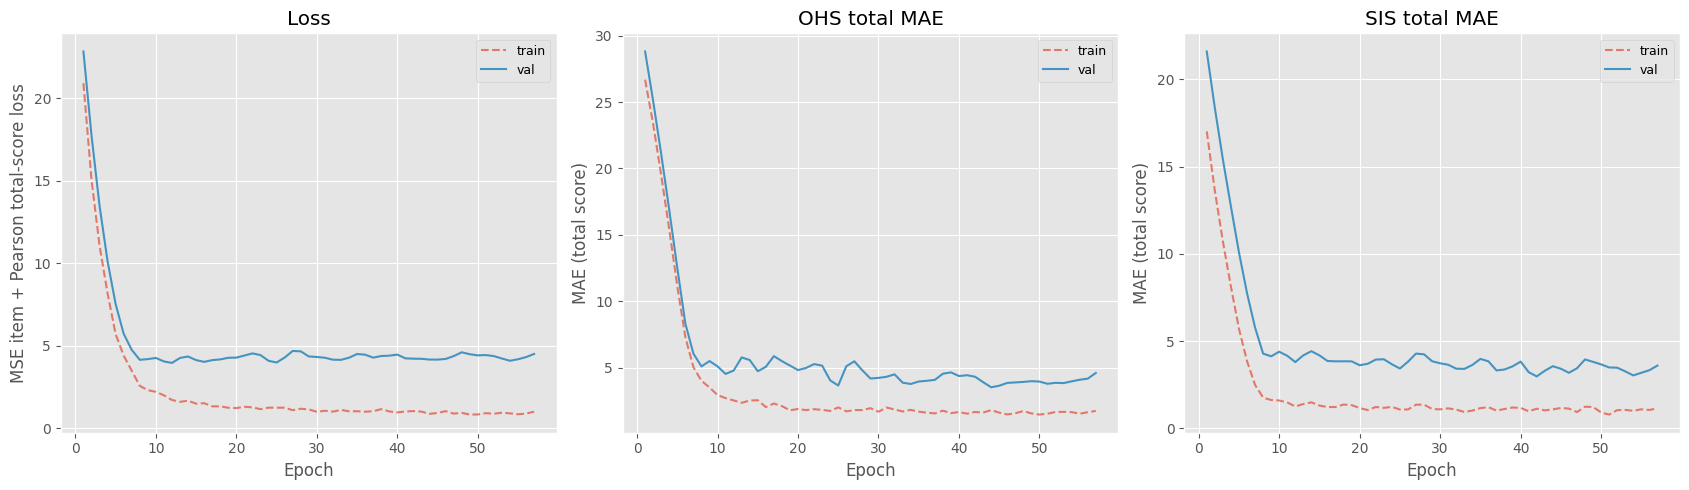

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

axes[0].plot(history_df["epoch"], history_df["train_loss"], linestyle="--", alpha=0.7, label="train")
axes[0].plot(history_df["epoch"], history_df["val_loss"],   alpha=0.9,              label="val")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE item + Pearson total-score loss")
axes[0].set_title("Loss")
axes[0].legend(fontsize=9)

axes[1].plot(history_df["epoch"], history_df["train_ohs_mae"], linestyle="--", alpha=0.7, label="train")
axes[1].plot(history_df["epoch"], history_df["val_ohs_mae"],   alpha=0.9,              label="val")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE (total score)")
axes[1].set_title("OHS total MAE")
axes[1].legend(fontsize=9)

axes[2].plot(history_df["epoch"], history_df["train_sis_mae"], linestyle="--", alpha=0.7, label="train")
axes[2].plot(history_df["epoch"], history_df["val_sis_mae"],   alpha=0.9,              label="val")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("MAE (total score)")
axes[2].set_title("SIS total MAE")
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

## Evaluation

Predictions are collected on held-out test patients. Per-item metrics (MAE, RMSE, R², Pearson r) are computed identically to the accepted paper. Total scores are reconstructed by summing per-item predictions.

In [13]:
def collect_predictions(artifact: dict) -> pd.DataFrame:
    rows  = []
    model = artifact["model"]
    model.eval()
    loader = make_loader(
        artifact["test_ids"], artifact["sensor_stats"], artifact["demo_stats"], shuffle=False
    )
    with torch.no_grad():
        for batch in loader:
            dev_batch = move_batch(batch)
            output    = model(dev_batch["x"], dev_batch["mask"], dev_batch["lengths"])
            sis_pred  = output["sis"].cpu().tolist()
            ohs_pred  = output["ohs"].cpu().tolist()
            for i in range(len(batch["patient"])):
                base = {
                    "patient"      : batch["patient"][i],
                    "clinical_time": pd.Timestamp(batch["clinical_time"][i]),
                    "history_days" : int(batch["lengths"][i]),
                }
                for name, truth, pred in zip(sis_targets, batch["sis"][i].tolist(), sis_pred[i]):
                    rows.append(base | {"outcome": "SIS", "item": name,
                                        "truth": float(truth), "prediction": float(pred)})
                for name, truth, pred in zip(ohs_targets, batch["ohs"][i].tolist(), ohs_pred[i]):
                    rows.append(base | {"outcome": "OHS", "item": name,
                                        "truth": float(truth), "prediction": float(pred)})
    return pd.DataFrame(rows)


def regression_metrics(frame: pd.DataFrame) -> pd.Series:
    y, p     = frame["truth"].to_numpy(), frame["prediction"].to_numpy()
    pearson  = np.corrcoef(y, p)[0, 1] if (len(y) > 1 and np.std(y) > 0 and np.std(p) > 0) else np.nan
    residual = y - p
    sst      = np.square(y - y.mean()).sum()
    r2       = 1 - np.square(residual).sum() / sst if sst > 0 else np.nan
    return pd.Series({"n": len(frame), "MAE": np.abs(residual).mean(),
                      "RMSE": np.sqrt(np.square(residual).mean()), "R2": r2, "Pearson": pearson})


def grouped_metrics(frame: pd.DataFrame, group_cols: list) -> pd.DataFrame:
    rows = []
    for keys, group in frame.groupby(group_cols):
        keys = keys if isinstance(keys, tuple) else (keys,)
        rows.append(dict(zip(group_cols, keys)) | regression_metrics(group).to_dict())
    return pd.DataFrame(rows).set_index(group_cols)

In [14]:
predictions = collect_predictions(artifact)

print("=== Overall per-item metrics ===")
display(grouped_metrics(predictions, ["outcome"]))

print("\n=== Per-item metrics ===")
display(grouped_metrics(predictions, ["outcome", "item"]))

print("\n=== Per-patient metrics ===")
display(grouped_metrics(predictions, ["patient", "outcome"]))

=== Overall per-item metrics ===


,n,MAE,RMSE,R2,Pearson
outcome,,,,,
OHS,144.0,1.600656,1.821994,-1.864367,-0.461210
SIS,72.0,0.979129,1.223769,-0.500216,0.076623



=== Per-item metrics ===


n       MAE      RMSE         R2   Pearson
outcome item                                                 
OHS     ohs-01  12.0  1.552496  1.625913  -6.464260  0.006894
        ohs-02  12.0  1.650919  1.809881 -12.102677 -0.563786
        ohs-03  12.0  1.970529  2.174982 -10.545743 -0.588180
        ohs-04  12.0  1.373542  1.758258  -1.225860 -0.061609
        ohs-05  12.0  1.511275  1.697619  -1.044312 -0.031942
        ohs-06  12.0  1.306779  1.492874  -1.766628 -0.542293
        ohs-07  12.0  1.857128  2.059841  -4.710131 -0.356354
        ohs-08  12.0  1.683640  1.889031  -7.709405 -0.249705
        ohs-09  12.0  1.338061  1.503898  -2.877215 -0.182953
        ohs-10  12.0  1.542803  1.881384 -14.928234 -0.720192
        ohs-11  12.0  2.048422  2.261607  -3.184891  0.540955
        ohs-12  12.0  1.372279  1.502164  -0.431434 -0.811585
SIS     sis-01  12.0  0.934041  1.042070  -0.221649  0.320647
        sis-02  12.0  0.550389  0.609290  -0.527366 -0.229684
        sis-03  12.0  0.722046  0.892886  -0.594492 -0.373685
        sis-04  12.0  0.915288  1.190705  -0.908038 -0.291505
        sis-05  12.0  1.396761  1.756050  -2.700453 -0.392076
        sis-06  12.0  1.356250  1.493248  -0.414492  0.070450


=== Per-patient metrics ===


n       MAE      RMSE        R2   Pearson
patient outcome                                              
2       OHS      48.0  1.207430  1.418495 -2.514742 -0.149331
        SIS      24.0  1.321129  1.611968 -1.856303 -0.316670
9       OHS      48.0  2.272820  2.353837 -2.413216 -0.523097
        SIS      24.0  0.776615  0.872927  0.421722  0.744038
14      OHS      48.0  1.321719  1.551226 -1.342256 -0.563148
        SIS      24.0  0.839643  1.064139 -2.706007  0.133014

=== Total-score metrics (train) ===


,n,MAE,RMSE,R2,Pearson
outcome,,,,,
OHS,48.0,2.556024,3.262981,0.817994,0.906350
SIS,48.0,1.256892,1.666082,0.834378,0.915717



=== Total-score metrics (test) ===


,n,MAE,RMSE,R2,Pearson
outcome,,,,,
OHS,12.0,12.922441,14.485496,-10.108625,-0.455100
SIS,12.0,4.016979,4.797670,-1.376014,-0.182581


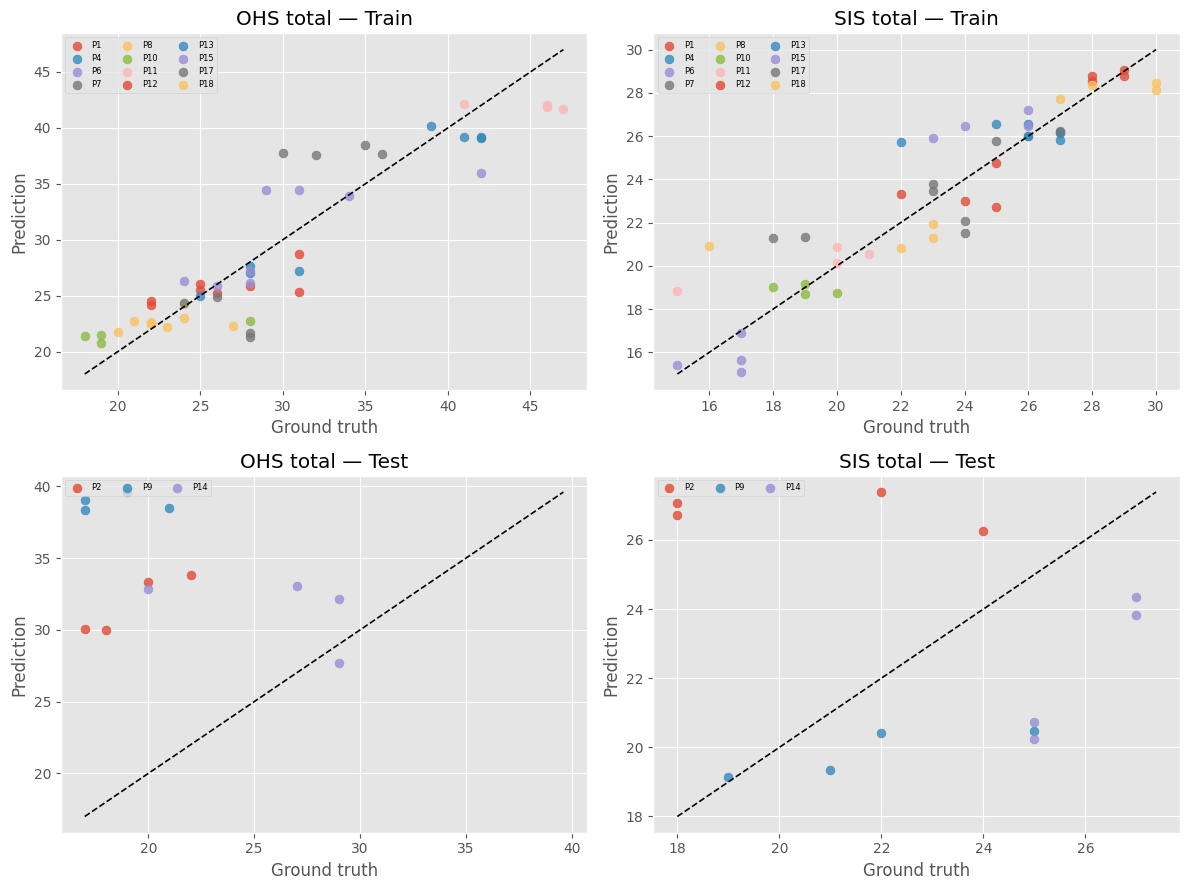

In [15]:
train_preds = collect_predictions({**artifact, "test_ids": artifact["train_ids"]})

total_predictions = predictions.groupby(
    ["patient", "clinical_time", "history_days", "outcome"], as_index=False
)[["truth", "prediction"]].sum()

train_total = train_preds.groupby(
    ["patient", "clinical_time", "history_days", "outcome"], as_index=False
)[["truth", "prediction"]].sum()

print("=== Total-score metrics (train) ===")
display(grouped_metrics(train_total, ["outcome"]))

print("\n=== Total-score metrics (test) ===")
display(grouped_metrics(total_predictions, ["outcome"]))

outcomes = sorted(total_predictions["outcome"].unique())
fig, axes = plt.subplots(2, len(outcomes), figsize=(6 * len(outcomes), 9))

for col, outcome in enumerate(outcomes):
    for row, (label, frame) in enumerate([("Train", train_total), ("Test", total_predictions)]):
        ax = axes[row, col]
        sub = frame[frame["outcome"] == outcome]
        for patient, pf in sub.groupby("patient"):
            ax.scatter(pf["truth"], pf["prediction"], label=f"P{patient}", alpha=0.8, s=40)
        lo = min(sub["truth"].min(), sub["prediction"].min())
        hi = max(sub["truth"].max(), sub["prediction"].max())
        ax.plot([lo, hi], [lo, hi], color="black", linewidth=1.2, linestyle="--")
        ax.set_title(f"{outcome} total — {label}")
        ax.set_xlabel("Ground truth")
        ax.set_ylabel("Prediction")
        ax.legend(fontsize=6, ncol=3, loc="upper left")

plt.tight_layout()
plt.show()

## Learned Feature Gate Weights

Inspecting the final gate weights shows which features the model emphasised for each target after training — useful for comparing with the initial SHAP priors.

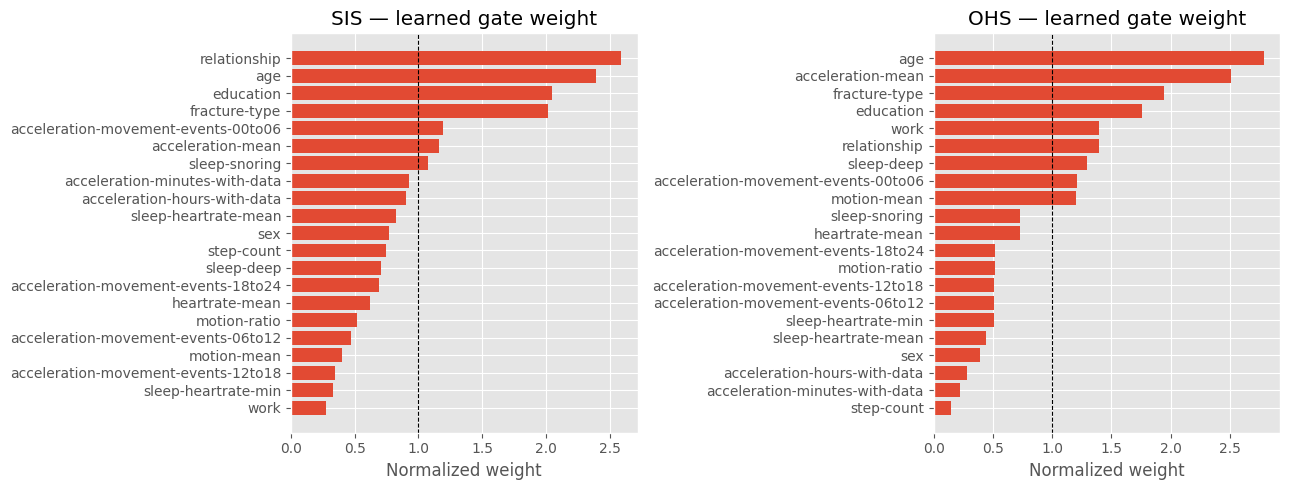

,SIS_learned,OHS_learned
feature,,
relationship,2.590,1.395
age,2.394,2.784
education,2.051,1.756
fracture-type,2.018,1.944
acceleration-movement-events-00to06,1.193,1.210
acceleration-mean,1.162,2.513
sleep-snoring,1.073,0.731
acceleration-minutes-with-data,0.927,0.227
acceleration-hours-with-data,0.903,0.278


In [16]:
model = artifact["model"]
with torch.no_grad():
    sis_w = torch.nn.functional.softplus(model.sis_gate.raw).cpu().numpy()
    ohs_w = torch.nn.functional.softplus(model.ohs_gate.raw).cpu().numpy()
sis_w = sis_w / sis_w.mean()
ohs_w = ohs_w / ohs_w.mean()

learned_df = pd.DataFrame({
    "feature"    : input_cols,
    "SIS_learned": sis_w,
    "OHS_learned": ohs_w,
})

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col, label in zip(axes, ["SIS_learned", "OHS_learned"], ["SIS", "OHS"]):
    s = learned_df.set_index("feature")[col].sort_values(ascending=False)
    ax.barh(s.index[::-1], s.values[::-1])
    ax.set_title(f"{label} — learned gate weight")
    ax.set_xlabel("Normalized weight")
    ax.axvline(1.0, color="black", linestyle="--", linewidth=0.8)
plt.tight_layout()
plt.show()

display(learned_df.set_index("feature").sort_values("SIS_learned", ascending=False).round(3))